In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/)
# Temporary files can go to /kaggle/temp/ but won't be saved outside the session

# GEARS benchmark — Adamson dataset

Evaluates GEARS against a simple average-perturbation baseline on the **Adamson** single-gene perturbation dataset.

**Dataset:** ~65 900 cells · 5 060 genes · 81 single-gene perturbations  
**Task:** predict gene expression for held-out single-gene perturbations  
**Split:** random 57 / 7 / 17 train / val / test across perturbations

| Metric | GEARS | Average baseline |
|---|:---:|:---:|
| RMSE | ✓ | ✓ |
| Pearson (raw) | ✓ | ✓ |
| Pearson (delta) | ✓ | — (constant predictor has zero delta) |
| Centroid accuracy | ✓ | ✓ |

## 1 · Environment setup

In [1]:
%%capture
# Install required packages (output suppressed)
!pip install -q scanpy python-igraph louvain
!pip install -q torch-geometric anndata pytorch-lightning
!pip install -q cell-gears


In [2]:
import random
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Compatibility patch required by some GEARS versions
pd.Series.nonzero = lambda self: self.to_numpy().nonzero()

from gears import PertData, GEARS

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | GPU available: {torch.cuda.is_available()} | device: {DEVICE}")

PyTorch 2.5.1+cu118 | GPU available: True | device: cuda


## 2 · Load data

In [3]:
%%capture
pert_data = PertData('./data')
pert_data.load(data_name='adamson')

In [4]:
adata = pert_data.adata
print(adata)

conditions = adata.obs["condition"].values
gene_names = np.array(
    adata.var["gene_name"] if "gene_name" in adata.var.columns else adata.var_names
)

X = adata.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

print(f"\nTotal cells: {len(conditions)} | Unique conditions: {len(np.unique(conditions))}")

View of AnnData object with n_obs × n_vars = 65899 × 5060
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'



Total cells: 65899 | Unique conditions: 82


## 3 · Train / val / test split

In [5]:
all_perturbations = sorted([c for c in np.unique(conditions) if c != "ctrl"])

train_val_perts, test_perturbations = train_test_split(
    all_perturbations, test_size=0.2, random_state=SEED, shuffle=True
)
train_perturbations, val_perturbations = train_test_split(
    train_val_perts, test_size=0.1, random_state=SEED, shuffle=True
)

print(f"Train: {len(train_perturbations)} | Val: {len(val_perturbations)} | Test: {len(test_perturbations)}")

pert_data.split = "manual_random_single_pert"
pert_data.set2conditions = {
    "train": train_perturbations + ["ctrl"],
    "val":   val_perturbations,
    "test":  test_perturbations,
}

Train: 57 | Val: 7 | Test: 17


In [6]:
%%capture
pert_data.get_dataloader(batch_size=32, test_batch_size=128)

## 4 · Ground-truth centroids and baseline

The **average-perturbation baseline** predicts the mean expression of all training perturbations for every test perturbation. It also serves as the **reference** for computing delta metrics.

In [7]:
# Mean expression per perturbation, computed on perturbed cells only
pert_mask = conditions != "ctrl"
df_pert = pd.DataFrame(X[pert_mask], columns=gene_names)
df_pert["condition"] = conditions[pert_mask]
ground_truth_centroids = df_pert.groupby("condition")[gene_names].mean()

# Reference = mean across all training perturbations.
# Used both as the constant baseline prediction and as the delta origin.
reference = ground_truth_centroids.loc[train_perturbations].mean(axis=0).values

print(f"Ground-truth centroids: {len(ground_truth_centroids)} perturbations")
print(f"Reference vector shape: {reference.shape}")

Ground-truth centroids: 82 perturbations
Reference vector shape: (5060,)


## 5 · Train GEARS

In [8]:
%%capture
gears_model = GEARS(pert_data, device=DEVICE)
gears_model.model_initialize(hidden_size=64)
gears_model.train(epochs=20)
print("Training complete")

## 6 · Predict on test perturbations

In [9]:
# GEARS expects bare gene lists (without '+ctrl')
test_perts_input = [[g for g in p.split("+") if g != "ctrl"] for p in test_perturbations]
predictions = gears_model.predict(test_perts_input)
print(f"Predictions received for {len(predictions)} perturbations")

Predictions received for 17 perturbations


## 7 · Evaluation

**Pearson (delta)** measures correlation between the *predicted change* and the *true change* relative to the training mean — this better captures whether the model identifies the direction of the perturbation effect.  
It is only computed for GEARS: the average-perturbation baseline is constant, so its delta is identically zero and Pearson is undefined.

In [10]:
def centroid_accuracy(pred_dict, truth_dict):
    """Fraction of other test perturbations whose truth centroid is farther
    from the prediction than the correct one (nearest-neighbour ranking)."""
    perts = [p for p in pred_dict if p in truth_dict]
    scores = []
    for p in perts:
        d_correct = np.linalg.norm(pred_dict[p] - truth_dict[p])
        d_others = [np.linalg.norm(pred_dict[p] - truth_dict[q]) for q in perts if q != p]
        if d_others:
            scores.append(np.mean([d_correct < d for d in d_others]))
    return float(np.mean(scores))


# ── Build prediction / truth dictionaries ────────────────────────────────────
gears_pred_dict = {}
avg_pred_dict   = {}
truth_dict      = {}

for pert in test_perturbations:
    gene = pert.replace("+ctrl", "")
    key = (gene,) if (gene,) in predictions else gene
    if key not in predictions:
        print(f"[warning] Missing GEARS prediction for {pert}")
        continue
    gears_pred_dict[pert] = np.asarray(predictions[key]).flatten()
    avg_pred_dict[pert]   = reference.copy()
    truth_dict[pert]      = ground_truth_centroids.loc[pert].values.flatten()


# ── Per-perturbation scores ───────────────────────────────────────────────────
rows = []
for pert in truth_dict:
    true  = truth_dict[pert]
    gears = gears_pred_dict[pert]
    avg   = avg_pred_dict[pert]

    true_delta  = true  - reference
    gears_delta = gears - reference
    # avg delta is all zeros → Pearson with true_delta is undefined

    rows.append({
        "perturbation":        pert,
        "gears_rmse":          np.sqrt(mean_squared_error(true, gears)),
        "avg_rmse":            np.sqrt(mean_squared_error(true, avg)),
        "gears_pearson_raw":   pearsonr(true, gears)[0],
        "avg_pearson_raw":     pearsonr(true, avg)[0],
        "gears_pearson_delta": pearsonr(true_delta, gears_delta)[0],
    })

results_df = pd.DataFrame(rows)


# ── Aggregate summary ─────────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    "GEARS": [
        results_df["gears_rmse"].mean(),
        results_df["gears_pearson_raw"].mean(),
        results_df["gears_pearson_delta"].mean(),
        centroid_accuracy(gears_pred_dict, truth_dict),
    ],
    "Average perturbation baseline": [
        results_df["avg_rmse"].mean(),
        results_df["avg_pearson_raw"].mean(),
        float("nan"),
        centroid_accuracy(avg_pred_dict, truth_dict),
    ],
}, index=["RMSE", "Pearson (raw)", "Pearson (delta)", "Centroid accuracy"])

print("=== Per-perturbation results ===")
display(results_df.set_index("perturbation").round(4))
print("\n=== Aggregate summary ===")
display(summary_df.round(4))

=== Per-perturbation results ===


,gears_rmse,avg_rmse,gears_pearson_raw,avg_pearson_raw,gears_pearson_delta
perturbation,,,,,
SRP68+ctrl,0.0526,0.0444,0.9956,0.9965,0.1692
GMPPB+ctrl,0.0465,0.0360,0.9968,0.9978,0.1373
HSPA5+ctrl,0.0924,0.0922,0.9860,0.9855,0.2321
TELO2+ctrl,0.0480,0.0413,0.9964,0.9971,0.1868
PPWD1+ctrl,0.0659,0.0619,0.9928,0.9931,0.1997
PSMD4+ctrl,0.1102,0.1079,0.9787,0.9793,0.0858
SEC61A1+ctrl,0.0802,0.0701,0.9890,0.9912,-0.0791
UFL1+ctrl,0.0417,0.0363,0.9975,0.9980,0.2300
MRGBP+ctrl,0.0570,0.0513,0.9949,0.9956,0.1348



=== Aggregate summary ===


,GEARS,Average perturbation baseline
RMSE,0.0631,0.0582
Pearson (raw),0.9929,0.9932
Pearson (delta),0.1529,NaN
Centroid accuracy,0.5478,0.5000


## 8 · Visualisation

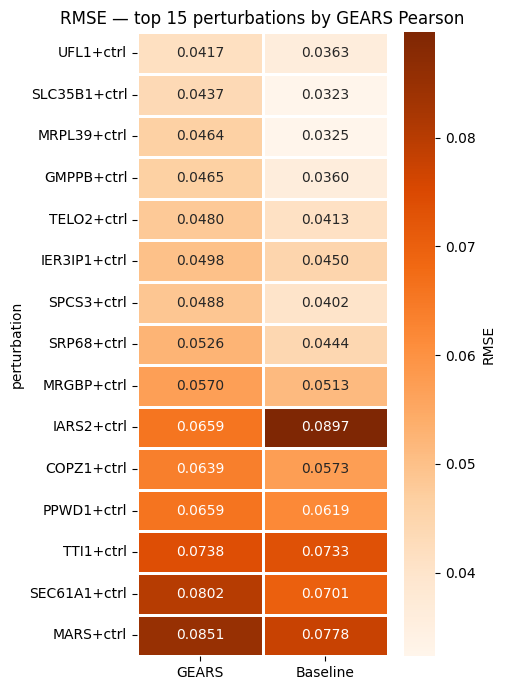

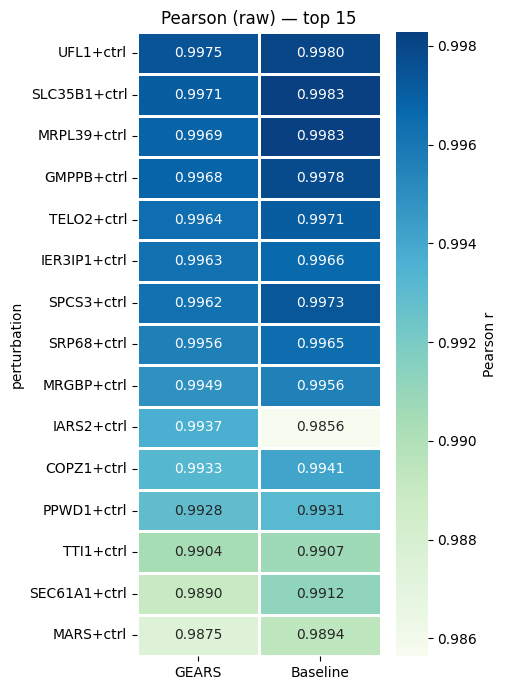

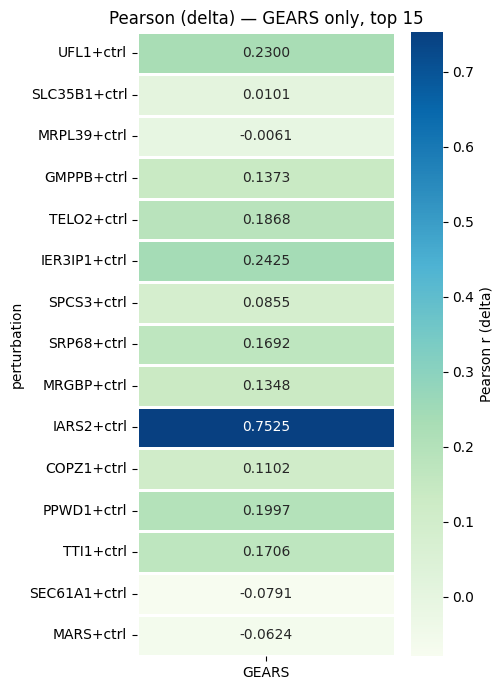

In [11]:
def heatmap(data, title, cmap, cbar_label, figsize=(5, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(data, annot=True, fmt=".4f", cmap=cmap,
                linewidths=2, linecolor="white",
                cbar_kws={"label": cbar_label}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()


plot_df = results_df.sort_values("gears_pearson_raw", ascending=False).set_index("perturbation")
top15   = plot_df.head(15)

heatmap(
    top15[["gears_rmse", "avg_rmse"]].rename(columns={"gears_rmse": "GEARS", "avg_rmse": "Baseline"}),
    title="RMSE — top 15 perturbations by GEARS Pearson",
    cmap="Oranges", cbar_label="RMSE"
)

heatmap(
    top15[["gears_pearson_raw", "avg_pearson_raw"]].rename(
        columns={"gears_pearson_raw": "GEARS", "avg_pearson_raw": "Baseline"}),
    title="Pearson (raw) — top 15",
    cmap="GnBu", cbar_label="Pearson r"
)

heatmap(
    top15[["gears_pearson_delta"]].rename(columns={"gears_pearson_delta": "GEARS"}),
    title="Pearson (delta) — GEARS only, top 15",
    cmap="GnBu", cbar_label="Pearson r (delta)"
)

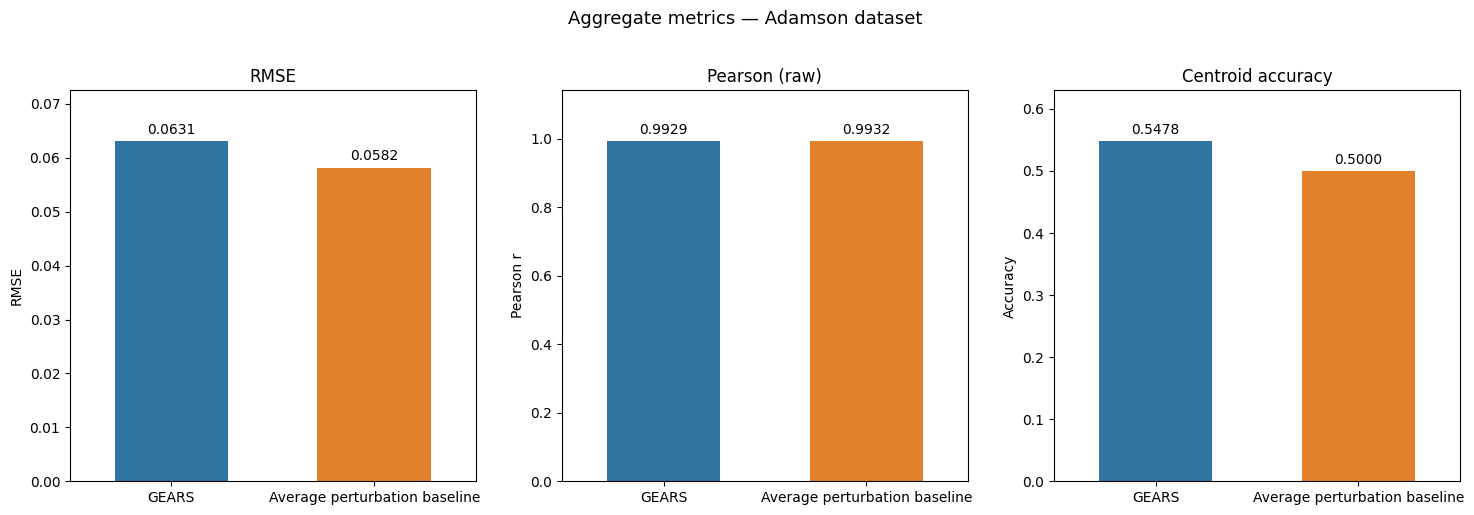

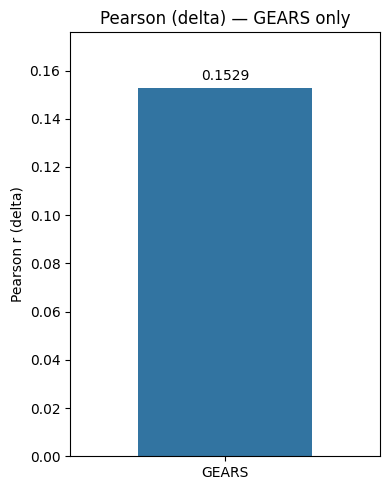

In [12]:
PALETTE = {"GEARS": "#1f77b4", "Average perturbation baseline": "#ff7f0e"}

def slim_barplot(ax, data, x, y, palette, title, ylabel):
    sns.barplot(data=data, x=x, y=y, palette=palette, ax=ax)
    for bar in ax.patches:
        w = bar.get_width()
        bar.set_width(w * 0.7)
        bar.set_x(bar.get_x() + w * 0.15)
    ymax = data[y].dropna().max()
    ax.set_ylim(0, ymax * 1.15)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.4f", padding=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")


summary_long = summary_df.T.reset_index().rename(columns={"index": "model"})

# Three metrics compared side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, ylabel in zip(
    axes,
    ["RMSE", "Pearson (raw)", "Centroid accuracy"],
    ["RMSE", "Pearson r", "Accuracy"]
):
    slim_barplot(ax, summary_long, x="model", y=metric,
                 palette=PALETTE, title=metric, ylabel=ylabel)
plt.suptitle("Aggregate metrics — Adamson dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Pearson (delta) — GEARS only
gears_only = summary_long[summary_long["model"] == "GEARS"]
fig, ax = plt.subplots(figsize=(4, 5))
slim_barplot(ax, gears_only, x="model", y="Pearson (delta)",
             palette={"GEARS": "#1f77b4"},
             title="Pearson (delta) — GEARS only", ylabel="Pearson r (delta)")
plt.tight_layout()
plt.show()